In [2]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\_aromatic_2025_2867_CClHO.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
594,"Hexanoic acid, 2-chlorophenyl ester",C12H15ClO2,226,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCC(=O)Oc1ccccc1Cl,CClHO
758,"3,5-Dichlorobenzaldehyde diacetate acetal",C11H10Cl2O4,276,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)OC(OC(C)=O)c1cc(Cl)cc(Cl)c1,CClHO
793,"2-Butanone, 3-chloro-3-methyl-4-(4-methylphenyl)-",C12H15ClO,210,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)C(C)(Cl)Cc1ccc(C)cc1,CClHO
1107,"Isobutyric acid, 2-chlorophenyl ester",C10H11ClO2,198,104316-25-8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)C(=O)Oc1ccccc1Cl,CClHO
1108,"Butyric acid, m-chlorophenyl ester",C10H11ClO2,198,29052-05-9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCC(=O)Oc1cccc(Cl)c1,CClHO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181522,"3-(2,6-Dichlorophenoxy)prop-1-yne",C9H6Cl2O,200,3598-66-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Clc1cccc(Cl)c1OCC#C,CClHO
181762,"Methyl 2,4,6-trichloro-3,5-dimethoxybenzoate",C10H9Cl3O4,298,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,COC(=O)c1c(Cl)c(OC)c(Cl)c(OC)c1Cl,CClHO
182150,"2-(4-Chlorophenyl)-2,4-diethoxy-2,5-dihydro-fu...",C14H15ClO4,282,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC1=CC(OCC)(OC1=O)c2ccc(Cl)cc2,CClHO
182229,"Cyclopropanecarboxylic acid, 2-(4-chlorophenyl...",C12H13ClO2,224,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)[C@@H]1C[C@H]1c2ccc(Cl)cc2,CClHO


In [ ]:
import deepchem as dc
import selfies as sf
import pandas as pd

# Assuming ms is your DataFrame
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:

        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(2867), np.int64(600)), y.shape: (np.int64(2867),), w.shape: (np.int64(2867),), task_names: [0]>

In [9]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[/C]': 3,
 '[/Cl]': 4,
 '[13CH1]': 5,
 '[13C]': 6,
 '[=13CH1]': 7,
 '[=13C]': 8,
 '[=Branch1]': 9,
 '[=Branch2]': 10,
 '[=C]': 11,
 '[=N]': 12,
 '[=O]': 13,
 '[=Ring1]': 14,
 '[=Ring2]': 15,
 '[Branch1]': 16,
 '[Branch2]': 17,
 '[C@@H1]': 18,
 '[C@H1]': 19,
 '[C@]': 20,
 '[C]': 21,
 '[Cl]': 22,
 '[N]': 23,
 '[O]': 24,
 '[P]': 25,
 '[Ring1]': 26,
 '[Ring2]': 27,
 '[S]': 28,
 '[\\-Ring1]': 29,
 '[\\C]': 30,
 '[\\Cl]': 31,
 '[\\O]': 32,
 '[nop]': 33}

In [10]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [12]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 2542
📦 Validation set size: 0
📦 Test set size: 325


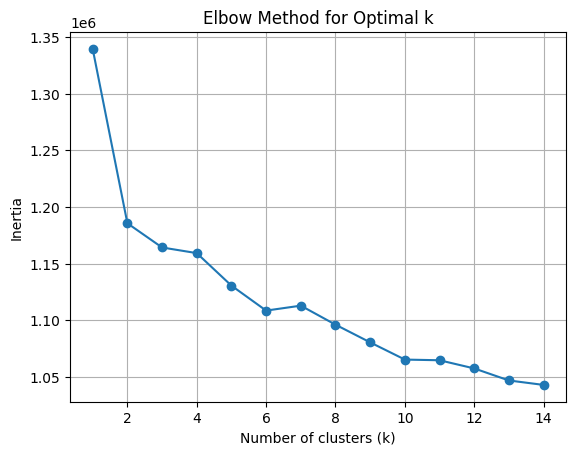

🔍 Elbow point detected at k = 5


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [14]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=3,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splittin

In [15]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(3):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (269, 600)
Cluster 1 shape: (638, 600)
Cluster 2 shape: (1635, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splittin

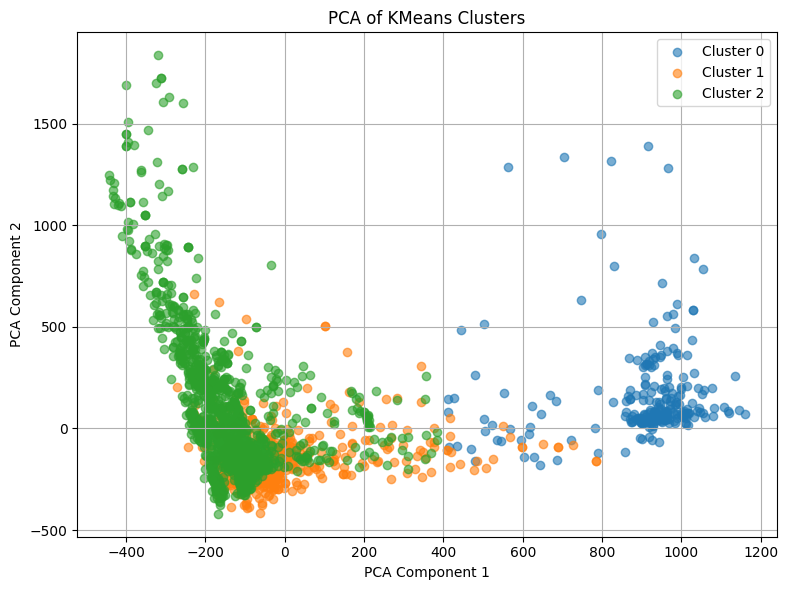

In [16]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [17]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [18]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")





✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_in

Cluster 0: size = 30, shape = (30, 600)
Cluster 1: size = 79, shape = (79, 600)
Cluster 2: size = 216, shape = (216, 600)


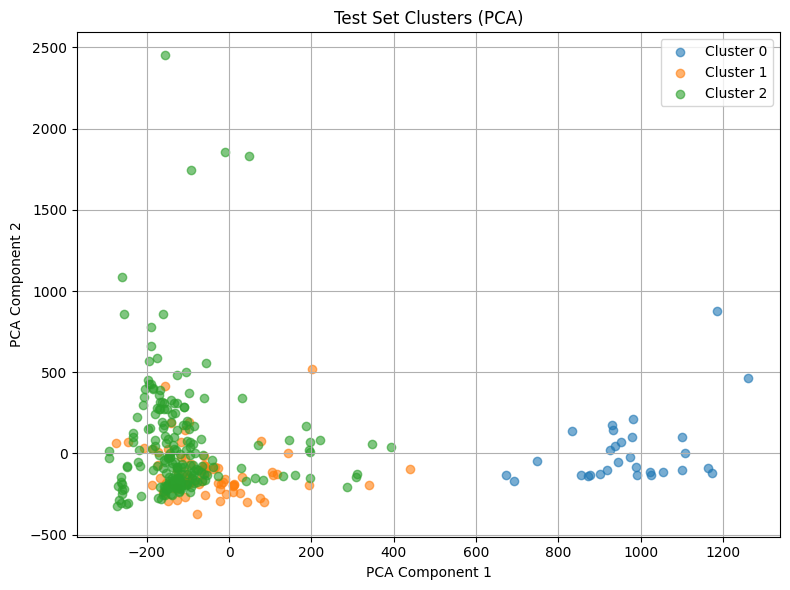

In [19]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(3):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 0.796710
Epoch 2/100 - Loss: 0.072789
Epoch 3/100 - Loss: 0.052079
Epoch 4/100 - Loss: 0.040558
Epoch 5/100 - Loss: 0.036666
Epoch 6/100 - Loss: 0.035311
Epoch 7/100 - Loss: 0.033872
Epoch 8/100 - Loss: 0.032523
Epoch 9/100 - Loss: 0.031274
Epoch 10/100 - Loss: 0.030108
Epoch 11/100 - Loss: 0.028845
Epoch 12/100 - Loss: 0.027640
Epoch 13/100 - Loss: 0.026616
Epoch 14/100 - Loss: 0.025546
Epoch 15/100 - Loss: 0.024561
Epoch 16/100 - Loss: 0.023395
Epoch 17/100 - Loss: 0.022714
Epoch 18/100 - Loss: 0.021796
Epoch 19/100 - Loss: 0.020899
Epoch 20/100 - Loss: 0.020436
Epoch 21/100 - Loss: 0.019300
Epoch 22/100 - Loss: 0.018659
Epoch 23/100 - Loss: 0.018358
Epoch 24/100 - Loss: 0.017325
Epoch 25/100 - Loss: 0.017151
Epoch 26/100 - Loss: 0.016626
Epoch 27/100 - Loss: 0.015645
Epoch 28/100 - Loss: 0.015271
Epoch 29/100 - Loss: 0.014779
Epoch 30/100 - Loss: 0.014568
Epoch 31/100 - Loss: 0.013653
Epoch 32/100 - Loss: 0.013204
Epoch 33/100 - Loss: 0.012801
Epoch 34/100 - Loss

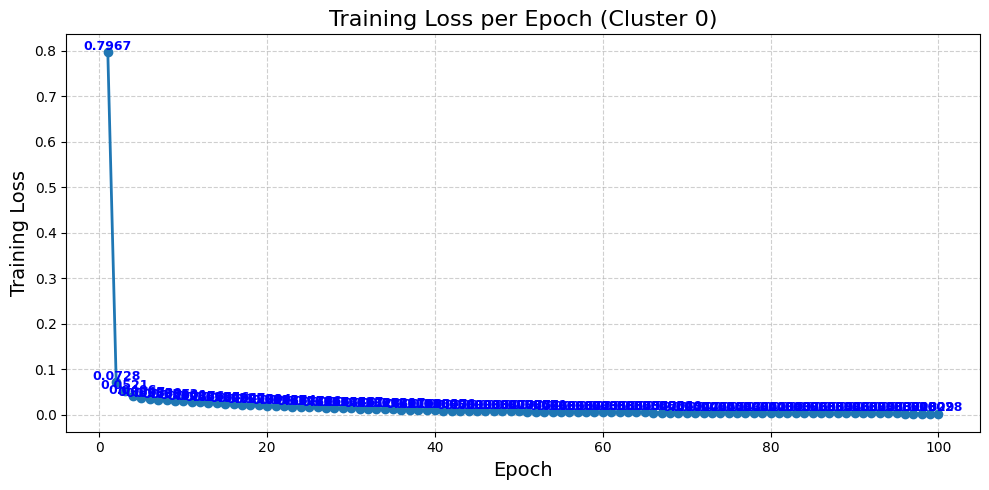

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\models_\model0000


In [20]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [21]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [22]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (30, 2414, 2)
Example prediction: [[1.0000000e+00 3.1657597e-38]
 [1.0000000e+00 6.8663625e-44]
 [1.0000000e+00 1.0580784e-36]
 ...
 [1.0000000e+00 2.0960258e-39]
 [1.0000000e+00 9.5211224e-41]
 [1.7056730e-35 1.0000000e+00]]


In [23]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [24]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [25]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: CCOC1=CC(OCC)(OC1=O)C2=CC=C(Cl)C=C2 | True: CCOC1=CC(OCC)(OC1=O)C2=CC=C(Cl)C=C2 | Tanimoto: 1.000
[1] Pred: CC=CC(CC=CO)C(O)C(=C)OC=CC=CCP | True: CC1=CC=C(OC(=O)C2=CC=C(Cl)C=C2)C=C1C | Tanimoto: 0.114
[2] Pred: OC(=O)C1=CC=CC=C1CCl | True: OC(=O)C1=CC=C(Cl)C=C1 | Tanimoto: 0.390
[3] Pred: ClCCCCCCOC(=O)C1=CC=CC=C1C | True: ClCCCCCCOC(=O)C1=CC=C(Cl)C=C1 | Tanimoto: 0.640
[4] Pred: CCCCCCCCCCCCCCOC(=O)C1=CC=C(Cl)C=C1 | True: CCCCCCCCCCCCOC(=O)C1=CC=C(Cl)C=C1 | Tanimoto: 1.000
[5] Pred: CCCCCCCCCCC(C)COC(=O)C1=CC=CC=C1Cl | True: CCCCCCCCCCCCC(CCC)OC(=O)C1=CC=CC=C1Cl | Tanimoto: 0.809
[6] Pred: CCCCCCCCCCCC(C)CCCOC(=O)C1=CC=CC=C1Cl | True: CCCCCCCCCCCCC(CC)OC(=O)C1=CC=CC=C1Cl | Tanimoto: 0.823
[7] Pred: CCC(C)CCCC(=O)C1=CC=CC=C1Cl | True: CCC(CC)OC(=O)C1=CC=CC=C1Cl | Tanimoto: 0.332
[8] Pred: CCCCCCOC(=O)C1=CC=CCC1C | True: CCC(C)OC(=O)C1=CC=CC=C1Cl | Tanimoto: 0.127
[9] Pred: CCCCCCCCCOC(C=C=O)CCl | True: CCCCCCCCCOC(=O)C1=CC=C(Cl)C=C1 | Tanimoto: 0.150
[10] Pred: ClC1=CC=CC(=C

Epoch 1/100 - Loss: 0.414746
Epoch 2/100 - Loss: 0.040867
Epoch 3/100 - Loss: 0.035100
Epoch 4/100 - Loss: 0.032576
Epoch 5/100 - Loss: 0.030608
Epoch 6/100 - Loss: 0.029032
Epoch 7/100 - Loss: 0.027322
Epoch 8/100 - Loss: 0.025757
Epoch 9/100 - Loss: 0.024317
Epoch 10/100 - Loss: 0.022925
Epoch 11/100 - Loss: 0.021702
Epoch 12/100 - Loss: 0.020457
Epoch 13/100 - Loss: 0.019299
Epoch 14/100 - Loss: 0.018013
Epoch 15/100 - Loss: 0.016081
Epoch 16/100 - Loss: 0.015892
Epoch 17/100 - Loss: 0.014701
Epoch 18/100 - Loss: 0.013709
Epoch 19/100 - Loss: 0.012593
Epoch 20/100 - Loss: 0.011858
Epoch 21/100 - Loss: 0.010897
Epoch 22/100 - Loss: 0.010207
Epoch 23/100 - Loss: 0.009586
Epoch 24/100 - Loss: 0.009003
Epoch 25/100 - Loss: 0.008503
Epoch 26/100 - Loss: 0.007972
Epoch 27/100 - Loss: 0.007591
Epoch 28/100 - Loss: 0.007019
Epoch 29/100 - Loss: 0.005728
Epoch 30/100 - Loss: 0.006440
Epoch 31/100 - Loss: 0.005860
Epoch 32/100 - Loss: 0.005639
Epoch 33/100 - Loss: 0.005319
Epoch 34/100 - Loss

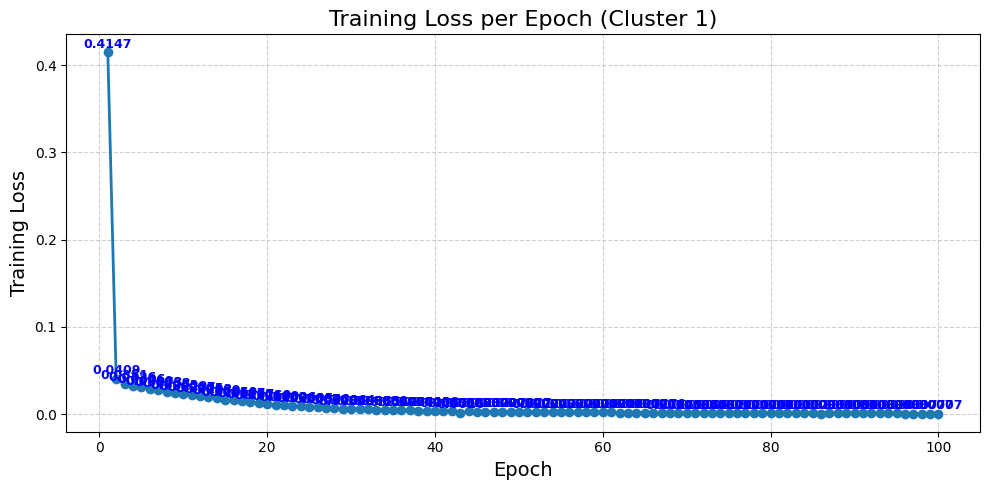

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with seed 123\models_\model1111


In [26]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [27]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (79, 2414, 2)
Example prediction: [[9.9999976e-01 2.3132061e-07]
 [9.9999881e-01 1.2471620e-06]
 [9.9999809e-01 1.8733036e-06]
 ...
 [9.9999881e-01 1.1829555e-06]
 [9.9999976e-01 1.8717343e-07]
 [3.1081490e-07 9.9999964e-01]]
[0] Pred: CC(=O)C=C=CC(C1)C1 | True: CC(=O)OC(C1=CC=C(Cl)C(Cl)=C1)C(Cl)(Cl)Cl | Tanimoto: 0.041
[1] Pred: ClCCOOCCOC=COCO | True: ClCCOCCOC1=CC=CC=C1Cl | Tanimoto: 0.099
[2] Pred: CCCC=C(Cl)C | True: ClC(=O)OC1=CC(Cl)=C(Cl)C=C1Cl | Tanimoto: 0.019
[3] Pred: OCCCC=COC | True: ClCCOCCOC1=CC=CC=C1 | Tanimoto: 0.073
[4] Pred: ClC=CC#CC=CCl | True: ClCCOC(=O)COC1=CC=C(Cl)C=C1Cl | Tanimoto: 0.036
[5] Pred: CC1=CC=C(OCC#CCl)C=C1 | True: CC1=CC=C(OCC#CCl)C=C1 | Tanimoto: 1.000
[6] Pred: CC1=CC(O)=C(C=C1Cl)C(=O)C2=CC=CC=C2 | True: CC1=CC(O)=C(C=C1Cl)C(=O)C2=CC=CC=C2 | Tanimoto: 1.000
[7] Pred: COC(=O)C1=CC=CC2=C1C=CC3=CC=C(Cl)C=C23 | True: COC(=O)C1=CC=CC2=C1C=CC3=CC=C(Cl)C=C23 | Tanimoto: 1.000
[8] Pred: COC1=CC(Cl)=C(Cl)C(Cl)=C1OC | True: COC1=CC(Cl)=

Epoch 1/100 - Loss: 0.178702
Epoch 2/100 - Loss: 0.040972
Epoch 3/100 - Loss: 0.036039
Epoch 4/100 - Loss: 0.032422
Epoch 5/100 - Loss: 0.029645
Epoch 6/100 - Loss: 0.019937
Epoch 7/100 - Loss: 0.025763
Epoch 8/100 - Loss: 0.024207
Epoch 9/100 - Loss: 0.022768
Epoch 10/100 - Loss: 0.021520
Epoch 11/100 - Loss: 0.020413
Epoch 12/100 - Loss: 0.016722
Epoch 13/100 - Loss: 0.018285
Epoch 14/100 - Loss: 0.017374
Epoch 15/100 - Loss: 0.016433
Epoch 16/100 - Loss: 0.015588
Epoch 17/100 - Loss: 0.014816
Epoch 18/100 - Loss: 0.013957
Epoch 19/100 - Loss: 0.013491
Epoch 20/100 - Loss: 0.012844
Epoch 21/100 - Loss: 0.012387
Epoch 22/100 - Loss: 0.011844
Epoch 23/100 - Loss: 0.011355
Epoch 24/100 - Loss: 0.010958
Epoch 25/100 - Loss: 0.010618
Epoch 26/100 - Loss: 0.010107
Epoch 27/100 - Loss: 0.009960
Epoch 28/100 - Loss: 0.009654
Epoch 29/100 - Loss: 0.009198
Epoch 30/100 - Loss: 0.008997
Epoch 31/100 - Loss: 0.008649
Epoch 32/100 - Loss: 0.008445
Epoch 33/100 - Loss: 0.008060
Epoch 34/100 - Loss

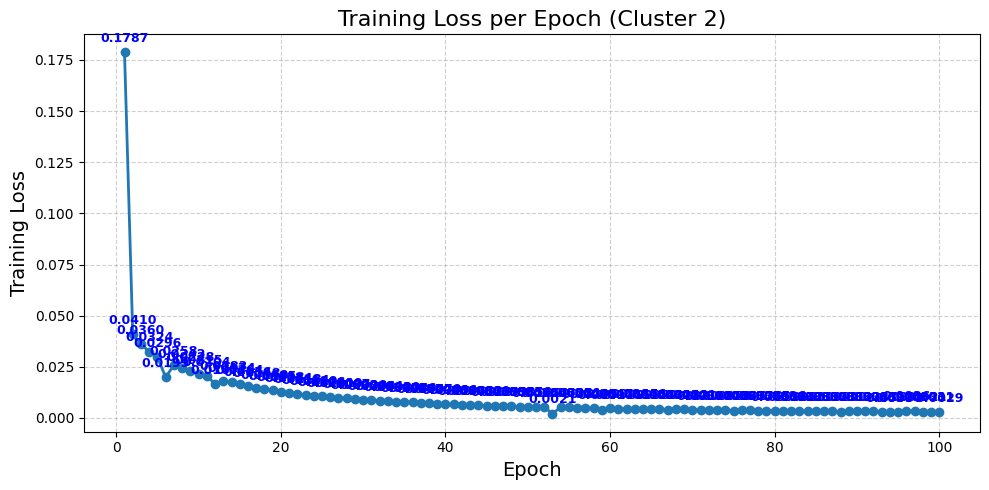

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with seed 123\models_\model2222


In [28]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [29]:
# === Load cluster 2 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_2867_CClHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 2
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_2
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])

evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (216, 2414, 2)
Example prediction: [[1.0000000e+00 9.8620034e-10]
 [9.9999988e-01 5.9911237e-08]
 [1.0000000e+00 3.8212068e-12]
 ...
 [1.0000000e+00 1.4385637e-12]
 [1.0000000e+00 2.0402580e-10]
 [1.4815657e-10 1.0000000e+00]]
[0] Pred: CCCC(=O)OC1=CC=CC(Cl)=C1 | True: CCCC(=O)OC1=CC=CC(Cl)=C1 | Tanimoto: 1.000
[1] Pred: ClC1=CC=C(OCC=C)C=C1 | True: ClC1=CC=C(OCC=C)C=C1 | Tanimoto: 1.000
[2] Pred: ClC1=CC=CC(OC(=O)OCC=C)=C1 | True: ClC1=CC=CC(OC(=O)OCC=C)=C1 | Tanimoto: 1.000
[3] Pred: ClCCCC=COCC=C(C)Cl | True: ClCCCCC(=O)OC1=CC=CC=C1Cl | Tanimoto: 0.081
[4] Pred: ClC=CC(Cl)=CC(=O)C=CCCl | True: ClC1=CC(Cl)=C(OC(=O)C=C)C=C1Cl | Tanimoto: 0.063
[5] Pred: ClC=C1C=C(OC(=O)CC2CCC2)C=C1Cl | True: ClC1=CC=CC(OC(=O)C2CCC2)=C1Cl | Tanimoto: 0.157
[6] Pred: ClC1=CC=CC=C1OC(C)OCCCC | True: COC(=O)CC1C(OC(=O)C(C)(C)C1=O)C2=CC=C(Cl)C=C2Cl | Tanimoto: 0.158
[7] Pred: COC(=O)C=CCCl | True: CC(=O)C1=CC2=CC(Cl)=CC=C2OC1=O | Tanimoto: 0.036
[8] Pred: CC(=O)OC=CC=C(C)CCl | True: CC(